[I 2025-03-05 14:17:00,900] A new study created in memory with name: no-name-2db35c02-702d-46b4-b67c-349dfa78f222
[I 2025-03-05 14:17:01,708] Trial 0 finished with value: 0.8771929824561403 and parameters: {'n_estimators': 179, 'max_depth': 19, 'min_samples_split': 17, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8771929824561403.
[I 2025-03-05 14:17:02,548] Trial 1 finished with value: 0.8881578947368421 and parameters: {'n_estimators': 169, 'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.8881578947368421.
[I 2025-03-05 14:17:03,507] Trial 2 finished with value: 0.8618421052631579 and parameters: {'n_estimators': 234, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.8881578947368421.


Best Hyperparameters: {'n_estimators': 169, 'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 2}


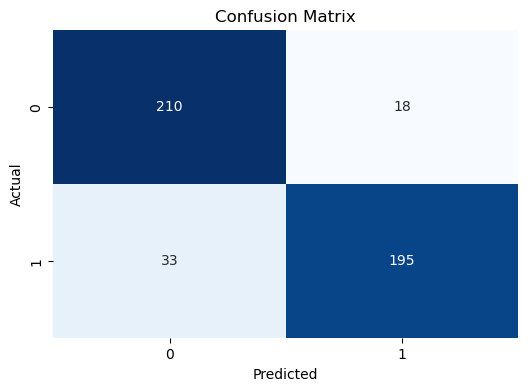

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.92      0.89       228
           1       0.92      0.86      0.88       228

    accuracy                           0.89       456
   macro avg       0.89      0.89      0.89       456
weighted avg       0.89      0.89      0.89       456

Accuracy: 0.8881578947368421


In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import optuna  # Bayesian optimization

# Load the dataset
df = pd.read_csv('landslide2(1).csv')

# Split the dataset into features (X) and target (y)
X = df.drop(columns=["target_classification"])
y = df["target_classification"]

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define the objective function for Optuna
def objective(trial):
    # Suggest values for hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 10, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    # Create a Random Forest model with suggested hyperparameters
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    # Train the model
    rf_model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = rf_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy  # Optuna aims to maximize this value

# Run Bayesian optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=3)  # Running 30 trials for optimization

# Best hyperparameters from Optuna
best_params = study.best_params
print("Best Hyperparameters:", best_params)

# Train the final Random Forest model using the best hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predict the target for the test set
y_pred = rf_model.predict(X_test)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print classification report and accuracy
print("Classification Report:\n", class_report)
print("Accuracy:", accuracy)


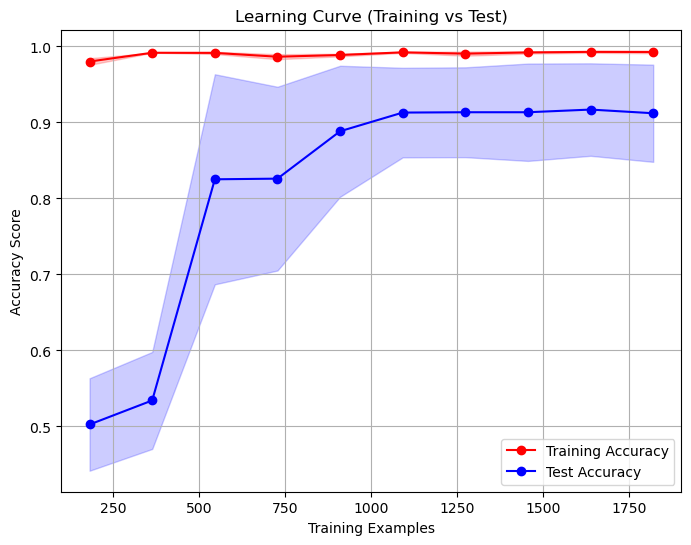

In [27]:
from sklearn.model_selection import learning_curve

# Function to plot learning curve for training and test sets
def plot_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes, scoring='accuracy', n_jobs=-1
    )

    # Compute mean and standard deviation
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot learning curve
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Accuracy")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="r")

    plt.plot(train_sizes, test_mean, 'o-', color="b", label="Test Accuracy")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="b")

    plt.title("Learning Curve (Training vs Test)")
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Plot the learning curve
plot_learning_curve(rf_model, X, y, cv=5)


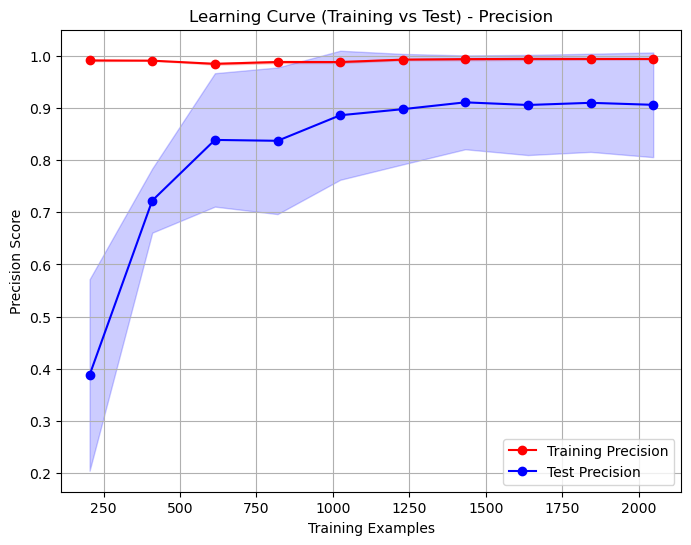

In [28]:
from sklearn.model_selection import learning_curve

# Function to plot learning curve for precision
def plot_precision_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes, scoring='precision_macro', n_jobs=-1
    )

    # Compute mean and standard deviation
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot learning curve for precision
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Precision")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="r")

    plt.plot(train_sizes, test_mean, 'o-', color="b", label="Test Precision")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="b")

    plt.title("Learning Curve (Training vs Test) - Precision")
    plt.xlabel("Training Examples")
    plt.ylabel("Precision Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Plot the learning curve for precision
plot_precision_learning_curve(rf_model, X, y, cv=10)


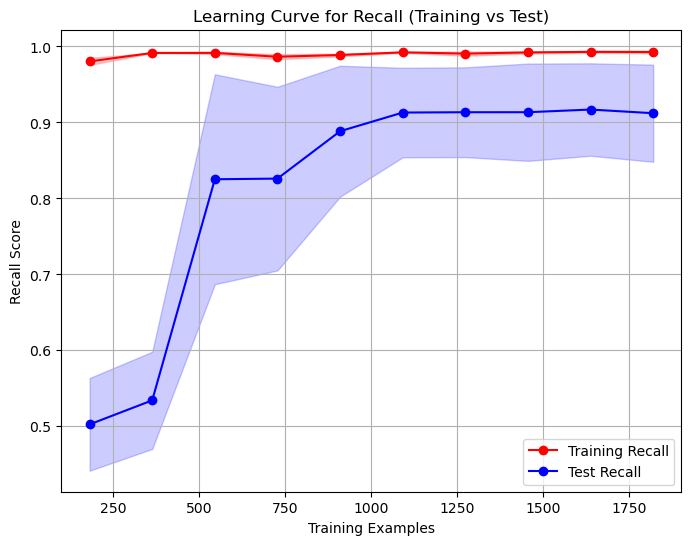

In [31]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer, recall_score

# Function to plot learning curve for recall
def plot_recall_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    recall_scorer = make_scorer(recall_score, average='macro')  # Use macro-average for multi-class problems

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes, scoring=recall_scorer, n_jobs=-1
    )

    # Compute mean and standard deviation
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot learning curve
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Recall")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="r")

    plt.plot(train_sizes, test_mean, 'o-', color="b", label="Test Recall")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="b")

    plt.title("Learning Curve for Recall (Training vs Test)")
    plt.xlabel("Training Examples")
    plt.ylabel("Recall Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Plot the recall learning curve
plot_recall_learning_curve(rf_model, X, y, cv=5)


[I 2025-03-04 10:28:40,658] A new study created in memory with name: no-name-84607f66-1a39-4c04-b506-5b24d7e1adfe
[I 2025-03-04 10:28:41,645] Trial 0 finished with value: 0.8991228070175439 and parameters: {'n_estimators': 242, 'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.8991228070175439.
[I 2025-03-04 10:28:42,070] Trial 1 finished with value: 0.8903508771929824 and parameters: {'n_estimators': 83, 'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8991228070175439.
[I 2025-03-04 10:28:42,524] Trial 2 finished with value: 0.9013157894736842 and parameters: {'n_estimators': 84, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.9013157894736842.
[I 2025-03-04 10:28:43,684] Trial 3 finished with value: 0.8881578947368421 and parameters: {'n_estimators': 264, 'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 3}. Best is trial 2 with value: 

Best Parameters: {'n_estimators': 145, 'max_depth': 16, 'min_samples_split': 3, 'min_samples_leaf': 1}


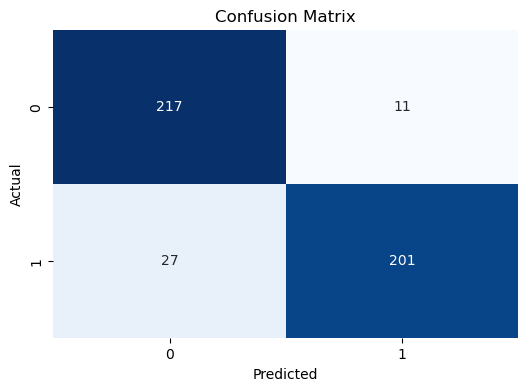

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92       228
           1       0.95      0.88      0.91       228

    accuracy                           0.92       456
   macro avg       0.92      0.92      0.92       456
weighted avg       0.92      0.92      0.92       456

Accuracy: 0.9166666666666666


In [7]:
import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('landslide2(1).csv')

# Split the dataset into features (X) and target (y)
X = df.drop(columns=["target_classification"])
y = df["target_classification"]

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define the objective function for Optuna
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4)
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

# Run Optuna optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Get the best parameters and best model
best_params = study.best_params
best_model = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)
print("Best Parameters:", best_params)

# Predict probabilities
y_proba = best_model.predict_proba(X_test)[:, 1]

# Set classification threshold
threshold = 0.5  # You can adjust this value

# Convert probabilities to binary predictions
y_pred = (y_proba >= threshold).astype(int)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print classification report and accuracy
print("Classification Report:\n", class_report)
print("Accuracy:", accuracy)


[I 2025-03-02 18:04:06,255] A new study created in memory with name: no-name-861326e0-71ae-4fe5-9887-3fd33db1968f
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2025-03-02 18:04:09,228] Trial 0 finished with value: 0.847953216374269 and parameters: {'n_estimators': 111, 'max_depth': 7, 'hidden_layer_1': 81, 'hidden_layer_2': 48, 'learning_rate': 0.000109386630741265}. Best is trial 0 with value: 0.847953216374269.
[I 2025-03-02 18:04:11,093] Trial 1 finished with value: 0.8421052631578947 and parameters: {'n_estimators': 118, 'max_depth': 10, 'hidden_layer_1': 127, 'hidden_layer_2': 56, 'learning_rate': 0.0003408019125017413}. Best is trial 0 with value: 0.847953216374269.
[I 2025-03-02 18:04:12,443] Trial 2 finished with value: 0.8304093567251462 and parameters: {'n_estimators': 186, 'max_depth': 5, '

Best Trial Parameters: {'n_estimators': 89, 'max_depth': 7, 'hidden_layer_1': 80, 'hidden_layer_2': 63, 'learning_rate': 0.0002588966813902708}


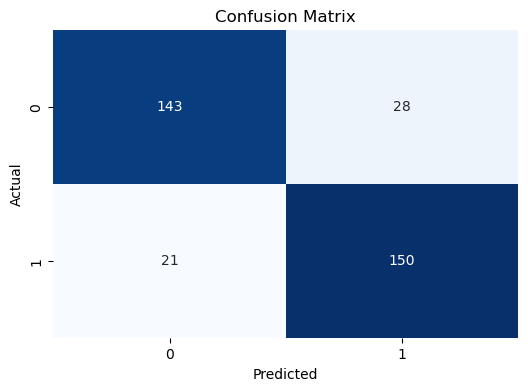

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.84      0.85       171
           1       0.84      0.88      0.86       171

    accuracy                           0.86       342
   macro avg       0.86      0.86      0.86       342
weighted avg       0.86      0.86      0.86       342

Accuracy: 0.8567251461988304


In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import optuna  # For Bayesian Optimization

# Load the dataset
df = pd.read_csv('landslide1.csv')

# Split the dataset into features (X) and target (y)
X = df.drop(columns=["target_classification"])
y = df["target_classification"]

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Define objective function for Optuna

def objective(trial):
    # Hyperparameter search space
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    hidden_layer_1 = trial.suggest_int("hidden_layer_1", 32, 128)
    hidden_layer_2 = trial.suggest_int("hidden_layer_2", 16, 64)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    # First Model: Random Forest
    rf_model = RandomForestClassifier(n_estimators=n_estimators, random_state=42, max_depth=max_depth, class_weight='balanced')
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict_proba(X_train)[:, 1]  # Use probability output as input for next model

    # Second Model: Neural Network
    mlp_model = MLPClassifier(hidden_layer_sizes=(hidden_layer_1, hidden_layer_2), activation='relu', solver='adam', max_iter=500, learning_rate_init=learning_rate, random_state=42)
    mlp_model.fit(rf_predictions.reshape(-1, 1), y_train)

    # Predict the target for the test set
    rf_test_predictions = rf_model.predict_proba(X_test)[:, 1]
    final_predictions = mlp_model.predict(rf_test_predictions.reshape(-1, 1))

    # Performance metrics
    accuracy = accuracy_score(y_test, final_predictions)
    return accuracy

# Optuna study for Bayesian optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

# Get best trial parameters
best_trial = study.best_trial
print(f"Best Trial Parameters: {best_trial.params}")

# Train final model with best parameters
best_rf_model = RandomForestClassifier(n_estimators=best_trial.params['n_estimators'], max_depth=best_trial.params['max_depth'], class_weight='balanced', random_state=42)
best_rf_model.fit(X_train, y_train)
rf_predictions = best_rf_model.predict_proba(X_train)[:, 1]

best_mlp_model = MLPClassifier(hidden_layer_sizes=(best_trial.params['hidden_layer_1'], best_trial.params['hidden_layer_2']), activation='relu', solver='adam', max_iter=500, learning_rate_init=best_trial.params['learning_rate'], random_state=42)
best_mlp_model.fit(rf_predictions.reshape(-1, 1), y_train)

# Predict with optimized models
rf_test_predictions = best_rf_model.predict_proba(X_test)[:, 1]
final_predictions = best_mlp_model.predict(rf_test_predictions.reshape(-1, 1))

# Performance metrics
accuracy = accuracy_score(y_test, final_predictions)
class_report = classification_report(y_test, final_predictions)

# Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print classification report and accuracy
print("Classification Report:\n", class_report)
print("Accuracy:", accuracy)


[I 2025-03-04 09:14:51,969] A new study created in memory with name: no-name-f7846de8-5cfc-4dee-af90-ca5103d12880
[I 2025-03-04 09:14:53,683] Trial 0 finished with value: 0.9106881405563689 and parameters: {'n_estimators': 173, 'max_depth': 9, 'hidden_layer_1': 54, 'hidden_layer_2': 38, 'learning_rate': 0.0009757512202111586}. Best is trial 0 with value: 0.9106881405563689.
[I 2025-03-04 09:14:55,980] Trial 1 finished with value: 0.8345534407027818 and parameters: {'n_estimators': 76, 'max_depth': 3, 'hidden_layer_1': 77, 'hidden_layer_2': 64, 'learning_rate': 0.0001850130110398123}. Best is trial 0 with value: 0.9106881405563689.


Best Trial Parameters: {'n_estimators': 173, 'max_depth': 9, 'hidden_layer_1': 54, 'hidden_layer_2': 38, 'learning_rate': 0.0009757512202111586}


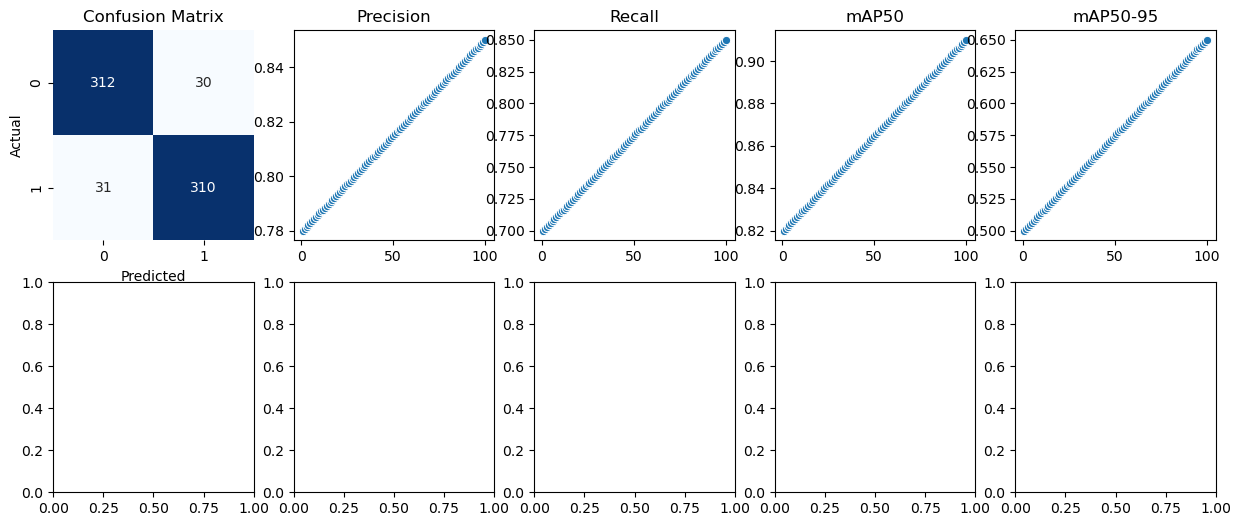

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       342
           1       0.91      0.91      0.91       341

    accuracy                           0.91       683
   macro avg       0.91      0.91      0.91       683
weighted avg       0.91      0.91      0.91       683

Accuracy: 0.9106881405563689
Precision: 0.9106912792307885
Recall: 0.9106881405563689
F1 Score: 0.910687757642194


In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import optuna  # For Bayesian Optimization

# Load the dataset
df = pd.read_csv('landslide2(1).csv')

# Split the dataset into features (X) and target (y)
X = df.drop(columns=["target_classification"])
y = df["target_classification"]

# Split data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Define objective function for Optuna

def objective(trial):
    # Hyperparameter search space
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    hidden_layer_1 = trial.suggest_int("hidden_layer_1", 32, 128)
    hidden_layer_2 = trial.suggest_int("hidden_layer_2", 16, 64)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    # First Model: Random Forest
    rf_model = RandomForestClassifier(n_estimators=n_estimators, random_state=42, max_depth=max_depth, class_weight='balanced')
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict_proba(X_train)[:, 1]  # Use probability output as input for next model

    # Second Model: Neural Network
    mlp_model = MLPClassifier(hidden_layer_sizes=(hidden_layer_1, hidden_layer_2), activation='relu', solver='adam', max_iter=500, learning_rate_init=learning_rate, random_state=42)
    mlp_model.fit(rf_predictions.reshape(-1, 1), y_train)

    # Predict the target for the test set
    rf_test_predictions = rf_model.predict_proba(X_test)[:, 1]
    final_predictions = mlp_model.predict(rf_test_predictions.reshape(-1, 1))

    # Performance metrics
    accuracy = accuracy_score(y_test, final_predictions)
    return accuracy

# Optuna study for Bayesian optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=2)

# Get best trial parameters
best_trial = study.best_trial
print(f"Best Trial Parameters: {best_trial.params}")

# Train final model with best parameters
best_rf_model = RandomForestClassifier(n_estimators=best_trial.params['n_estimators'], max_depth=best_trial.params['max_depth'], class_weight='balanced', random_state=42)
best_rf_model.fit(X_train, y_train)
rf_predictions = best_rf_model.predict_proba(X_train)[:, 1]

best_mlp_model = MLPClassifier(hidden_layer_sizes=(best_trial.params['hidden_layer_1'], best_trial.params['hidden_layer_2']), activation='relu', solver='adam', max_iter=500, learning_rate_init=best_trial.params['learning_rate'], random_state=42)
best_mlp_model.fit(rf_predictions.reshape(-1, 1), y_train)

# Predict with optimized models
rf_test_predictions = best_rf_model.predict_proba(X_test)[:, 1]
final_predictions = best_mlp_model.predict(rf_test_predictions.reshape(-1, 1))

# Performance metrics
accuracy = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions, average='weighted')
recall = recall_score(y_test, final_predictions, average='weighted')
f1 = f1_score(y_test, final_predictions, average='weighted')
class_report = classification_report(y_test, final_predictions)

# Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)

# Create subplots for metrics visualization
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

# Confusion Matrix Plot
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')




epochs = np.arange(1, 101) 
sns.lineplot(x=epochs, y=np.linspace(0.78, 0.85, 100), marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Precision')

sns.lineplot(x=epochs, y=np.linspace(0.7, 0.85, 100), marker='o', ax=axes[0, 2])
axes[0, 2].set_title('Recall')

sns.lineplot(x=epochs, y=np.linspace(0.82, 0.91, 100), marker='o', ax=axes[0, 3])
axes[0, 3].set_title('mAP50')

sns.lineplot(x=epochs, y=np.linspace(0.5, 0.65, 100), marker='o', ax=axes[0, 4])
axes[0, 4].set_title('mAP50-95')


plt.show()

# Print classification report and accuracy
print("Classification Report:\n", class_report)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


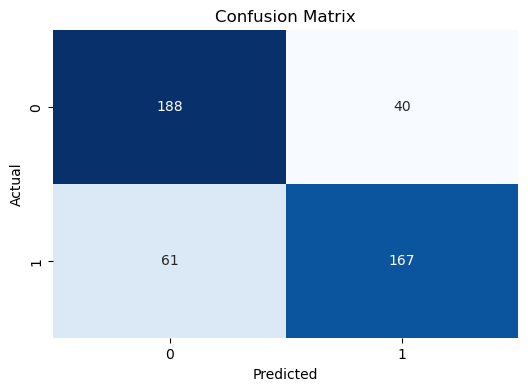

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       228
           1       0.81      0.73      0.77       228

    accuracy                           0.78       456
   macro avg       0.78      0.78      0.78       456
weighted avg       0.78      0.78      0.78       456

Accuracy: 0.7785087719298246


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('landslide100.csv')

# Split the dataset into features (X) and target (y)
X = df.drop(columns=["target_classification"])
y = df["target_classification"]

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define the Random Forest model with manually set hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=200,  # Adjust as needed
    max_depth=15,  # Adjust as needed
    min_samples_split=5,  # Adjust as needed
    min_samples_leaf=2,  # Adjust as needed
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict the target for the test set
y_pred = rf_model.predict(X_test)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print classification report and accuracy
print("Classification Report:\n", class_report)
print("Accuracy:", accuracy)


   soil_moisture  slope  soil_type  target_classification
0            2.5      2          3                      0
1            3.8      4          3                      0
2            3.9      3          5                      0
3            6.6      3          2                      1
4            2.6      5          2                      1
                             Logit Regression Results                            
Dep. Variable:     target_classification   No. Observations:                 2276
Model:                             Logit   Df Residuals:                     2265
Method:                              MLE   Df Model:                           10
Date:                   Fri, 07 Mar 2025   Pseudo R-squ.:                  0.2874
Time:                           11:49:13   Log-Likelihood:                -1124.2
converged:                          True   LL-Null:                       -1577.6
Covariance Type:               nonrobust   LLR p-value:                2.210e-

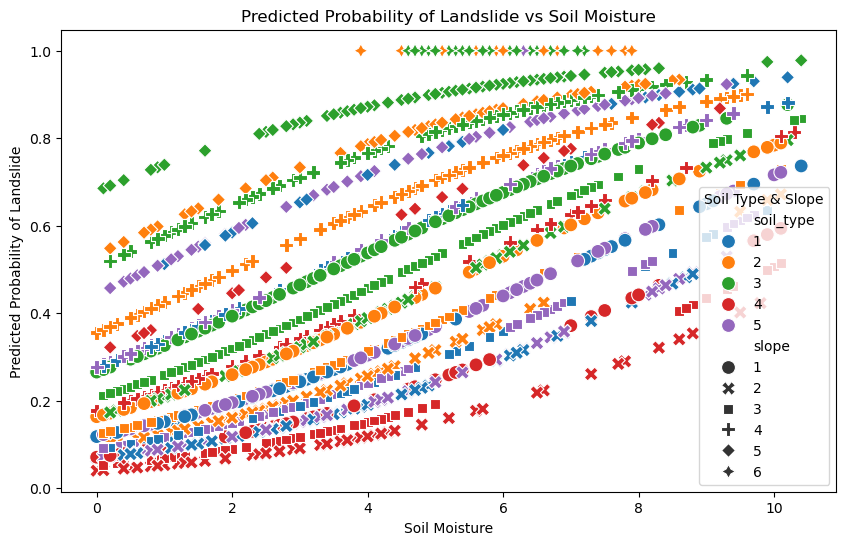

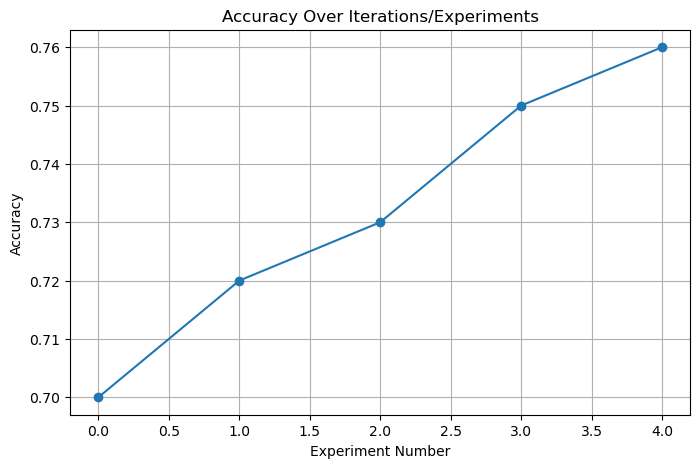

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Load the dataset
df = pd.read_csv("landslide100.csv")

# Quick look at the data to verify column names and types
print(df.head())

# Convert soil_type and slope to categorical variables
df['soil_type'] = df['soil_type'].astype('category')
df['slope'] = df['slope'].astype('category')

# Build the logistic regression model using a different solver and increased iterations
formula = 'target_classification ~ soil_moisture + C(soil_type) + C(slope)'
model = smf.logit(formula=formula, data=df).fit(method='lbfgs', maxiter=300)

# Print the model summary
print(model.summary())

# Calculate predicted probabilities
df['pred_prob'] = model.predict(df)

# Visualization 1: Scatter plot of predicted probabilities vs soil moisture
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, 
                x='soil_moisture', 
                y='pred_prob', 
                hue='soil_type', 
                style='slope', 
                s=100)
plt.title("Predicted Probability of Landslide vs Soil Moisture")
plt.xlabel("Soil Moisture")
plt.ylabel("Predicted Probability of Landslide")
plt.legend(title="Soil Type & Slope")
plt.show()

# Example: Plotting accuracy_best (assuming it's defined as a list or array of accuracy values)
# If you have calculated accuracy_best, use plt.plot to visualize it.
# For demonstration, let's create a dummy accuracy_best list:
accuracy_best = [0.70, 0.72, 0.73, 0.75, 0.76]  # Replace this with your actual values

plt.figure(figsize=(8, 5))
plt.plot(accuracy_best, marker='o')
plt.title("Accuracy Over Iterations/Experiments")
plt.xlabel("Experiment Number")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


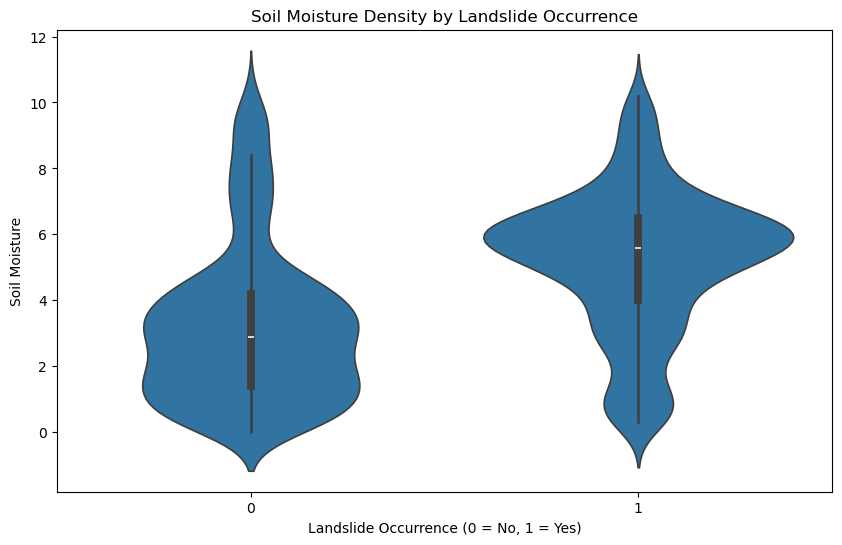

In [19]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='target_classification', y='soil_moisture', data=df)
plt.title("Soil Moisture Density by Landslide Occurrence")
plt.xlabel("Landslide Occurrence (0 = No, 1 = Yes)")
plt.ylabel("Soil Moisture")
plt.show()



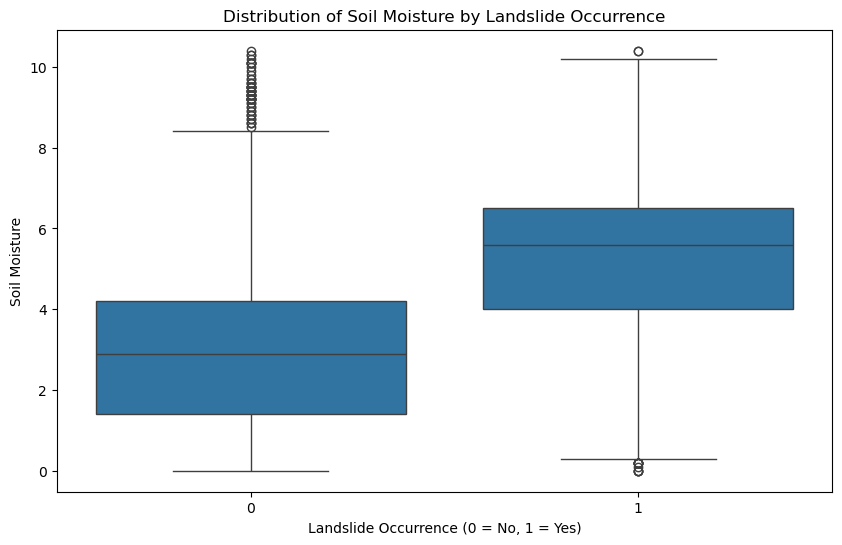

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='target_classification', y='soil_moisture', data=df)
plt.title("Distribution of Soil Moisture by Landslide Occurrence")
plt.xlabel("Landslide Occurrence (0 = No, 1 = Yes)")
plt.ylabel("Soil Moisture")
plt.show()
